In [6]:
# analysis/analyze_tldr.ipynb
# Author: Iskar Deng
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")
sys.path.append(project_root)
from utils import RESULTS_PATH

SCORE_DIR = os.path.join(RESULTS_PATH, "scores")

lase_data = []
bert_data = []

for fname in os.listdir(SCORE_DIR):
    fpath = os.path.join(SCORE_DIR, fname)
    if fname.endswith("_cs_LaSE.jsonl"):
        with open(fpath) as f:
            obj = json.load(f)
            variant = fname.split("_")[0]
            step = int(fname.split("_")[1])
            average = obj["average"]
            lase_data.append((variant, step, average))
    elif fname.endswith("_tldr_bertscore.jsonl"):
        with open(fpath) as f:
            obj = json.load(f)
            variant = fname.split("_")[0]
            step = int(fname.split("_")[1])
            average = obj["average"]
            bert_data.append((variant, step, average))

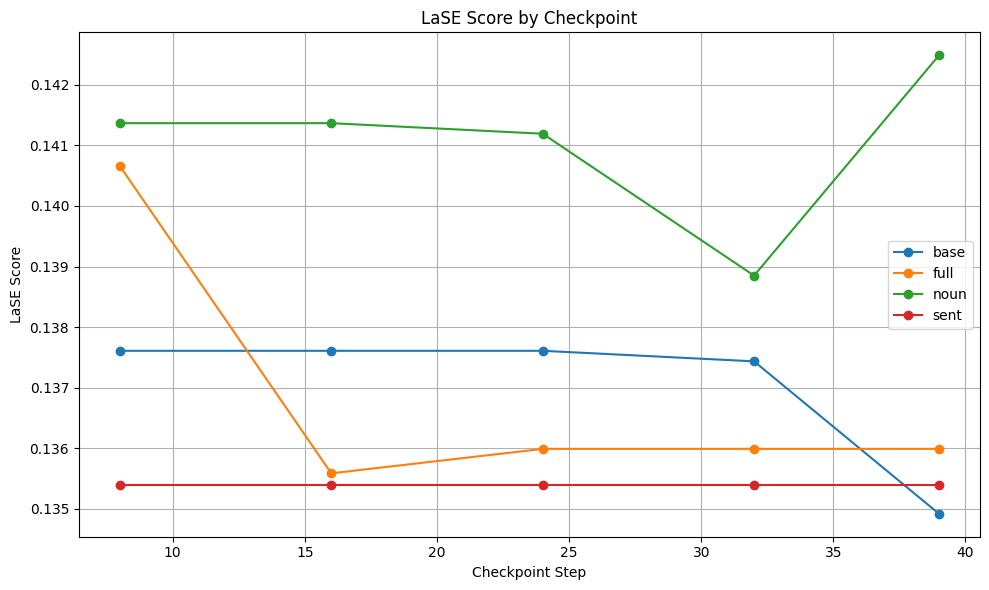

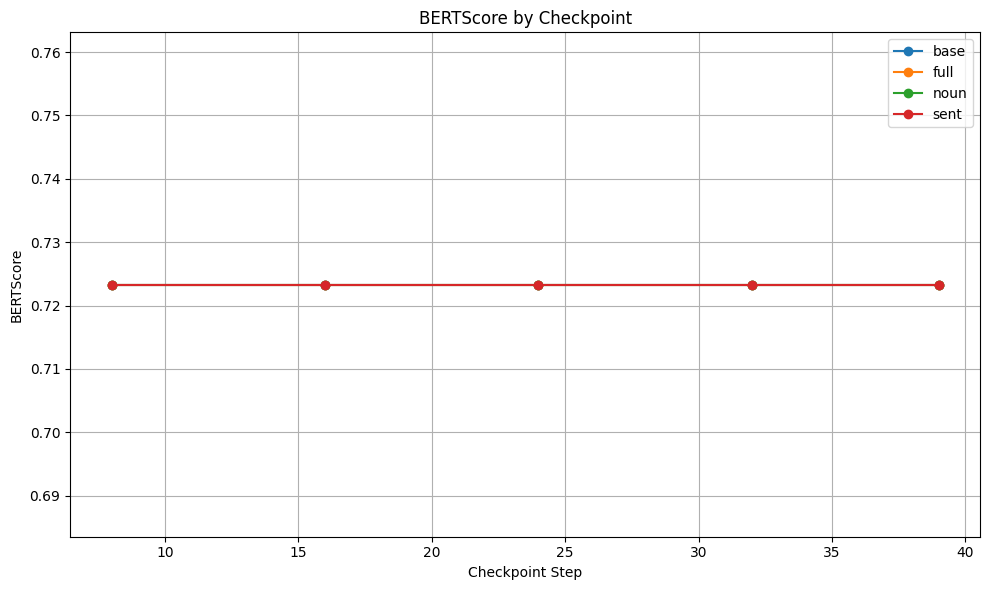

In [7]:
df_lase = pd.DataFrame(lase_data, columns=["variant", "step", "score"]).sort_values(by=["variant", "step"])
df_bert = pd.DataFrame(bert_data, columns=["variant", "step", "score"]).sort_values(by=["variant", "step"])

def plot_metric(df, title, ylabel):
    plt.figure(figsize=(10, 6))
    for variant, group in df.groupby("variant"):
        plt.plot(group["step"], group["score"], marker="o", label=variant)
    plt.title(title)
    plt.xlabel("Checkpoint Step")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric(df_lase, "LaSE Score by Checkpoint", "LaSE Score")

plot_metric(df_bert, "BERTScore by Checkpoint", "BERTScore")